### FinTrust Week 4 — Final Python Analysis & Validation
## Track: Data Analytics | Author: Olabisi Amusan
It builds on the Week 2 and Week 3 notebooks (which hold the 
exploratory charts) and focuses on what the final write-up depends on: a KPI check against the dashboard, 
and the significance tests behind each finding.
## To run it: put the customer and transaction CSV files in the same folder as this notebook, then run all cells. 
It needs pandas, numpy, matplotlib, seaborn and scipy
## How the tests work, in plain terms
• Chi-square test: compares two rates (for example, the flagged rate for international vs. domestic 
transactions) and asks whether the gap is bigger than random variation would normally produce. 
• ANOVA: the same question for the averages of several groups. 
• Correlation: how strongly two numeric columns move together (0 means not at all). 
• p-value: the probability of seeing a gap this big if there were really no difference. I treat p below 
0.05 as statistically clear. 
• Simulation: used for the segment-by-channel grid, where I picked the most extreme of 20 cells. I 
generate random data with no real differences and count how often chance alone produces a cell that 
extreme.

In [1]:
## Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)

In [7]:
# Small helpers so printed numbers read the same way as the written report
def pct1(x): return f"{x*100:.1f}%"
def pct2(x): return f"{x*100:.2f}%"
def p3(p): return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
def chi_square_p(successes_a, n_a, successes_b, n_b):
 """p-value for: is the rate in group A different from the rate in group B?"""
 table = [[successes_a, n_a - successes_a],
 [successes_b, n_b - successes_b]]
 return stats.chi2_contingency(table, correction=False)[1]

In [3]:
## Load and prepare the data
customers = pd.read_csv("FinTrust_Customer_Data - FinTrust_Customer_Data.csv")
transactions = pd.read_csv("FinTrust_Transaction_Data - FinTrust_Transaction_Data.csv")

transactions["Transaction_DateTime"] = pd.to_datetime(transactions["Transaction_DateTime"], format="%m/%d/%Y %H:%M")
transactions["Device_Type"] = transactions["Device_Type"].fillna("Unknown")
transactions["Location"] = transactions["Location"].fillna("Unknown")

In [4]:
# Two True/False helper columns used throughout
transactions["Successful"] = transactions["Transaction_Status"] == "Successful"
transactions["Flagged"] = transactions["Risk_Review_Flag"] == "Yes"

In [5]:
# Put the customer segment on every transaction
txn = transactions.merge(customers[["Customer_ID", "Customer_Segment"]], 
on="Customer_ID", how="left")
print("Customers:", len(customers), "| Transactions:", len(transactions))
print("Date range:", transactions["Transaction_DateTime"].min().date(), "to", 
transactions["Transaction_DateTime"].max().date())

Customers: 1500 | Transactions: 12000
Date range: 2026-01-01 to 2026-03-31


### KPI check against the dashboard¶
Each KPI is recalculated here directly from the CSV files and compared with what the Power BI cards show.

In [8]:
failed_or_reversed = transactions["Transaction_Status"].isin(["Failed", 
"Reversed"]).mean()
total_value = transactions["Amount_NGN"].sum()
kpi_table = pd.DataFrame({
 "KPI": ["Total Customers", "Total Transactions", "Failed/Reversed Rate",
 "Total Transaction Value", "Transaction Success Rate", "Risk Review Rate"],
 "Calculated from CSV": [f"{customers['Customer_ID'].nunique():,}", 
f"{len(transactions):,}",
pct2(failed_or_reversed), f"₦{total_value/1e6:.2f}M", pct2(transactions["Successful"].mean()), 
pct2(transactions["Flagged"].mean())], "Dashboard shows": ["1,500", "12,000", "7.97%", "₦560.48M", "90.47%", "19.60%"],})
kpi_table["Match?"] = kpi_table["Calculated from CSV"] == kpi_table["Dashboard shows"]
kpi_table

,KPI,Calculated from CSV,Dashboard shows,Match?
0,Total Customers,"1,500","1,500",True
1,Total Transactions,"12,000","12,000",True
2,Failed/Reversed Rate,7.97%,7.97%,True
3,Total Transaction Value,₦560.48M,₦560.48M,True
4,Transaction Success Rate,90.47%,90.47%,True
5,Risk Review Rate,19.60%,19.60%,True


### International vs. domestic transactions¶
Claim: international transactions are flagged for risk review more often, in every segment.

International: 177 of 480 flagged = 36.9%
Domestic:      2,175 of 11,520 flagged = 18.9%
Chi-square: p < 0.001

Flagged rate by segment (%):
                  Domestic  International
Customer_Segment                         
Everyday              18.6           37.2
Premium               19.6           36.9
SME                   18.6           40.6
Student               19.2           33.3


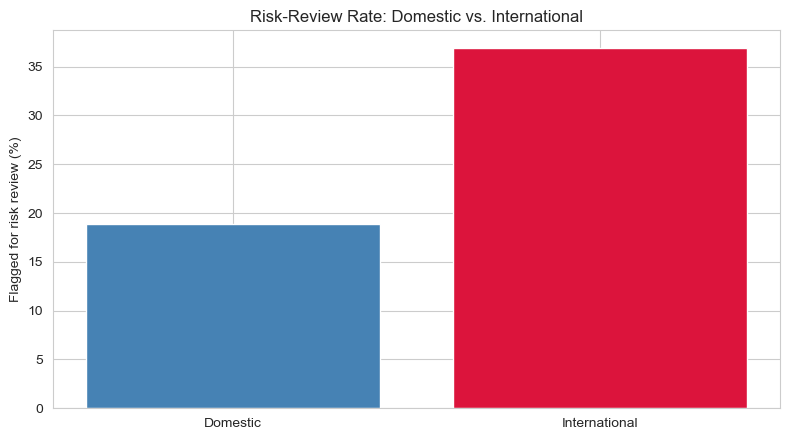

In [13]:
intl = txn[txn["International_Transaction"] == "Yes"]
dom = txn[txn["International_Transaction"] == "No"]

p_intl = chi_square_p(intl["Flagged"].sum(), len(intl), dom["Flagged"].sum(), len(dom))
print(f"International: {intl['Flagged'].sum()} of {len(intl)} flagged = {pct1(intl['Flagged'].mean())}")
print(f"Domestic:      {dom['Flagged'].sum():,} of {len(dom):,} flagged = {pct1(dom['Flagged'].mean())}")
print("Chi-square:", p3(p_intl))

print("\nFlagged rate by segment (%):")
by_segment = txn.groupby(["Customer_Segment", "International_Transaction"])["Flagged"].mean().unstack() * 100
by_segment.columns = ["Domestic", "International"]
print(by_segment.round(1))

plt.figure()
plt.bar(["Domestic", "International"], [dom["Flagged"].mean() * 100, intl["Flagged"].mean() * 100], color=["steelblue", "crimson"])
plt.ylabel("Flagged for risk review (%)")
plt.title("Risk-Review Rate: Domestic vs. International")
plt.tight_layout()
plt.show()

### High-value transactions¶
Claim: transactions in the top 10% of value for their own type are flagged more often, and this isn't just 
international transactions in disguise.

High-value: 355 of 1,202 flagged = 29.5%
Others:     1,997 of 10,798 flagged = 18.5%
Chi-square: p < 0.001

Domestic: high-value 28.6% (n=1,159) vs. other 17.8% (n=10,361), p < 0.001
International: high-value 53.5% (n=43) vs. other 35.2% (n=437), p = 0.018

Median amount: Deposit ₦22,094 vs. Airtime/Data ₦2,494


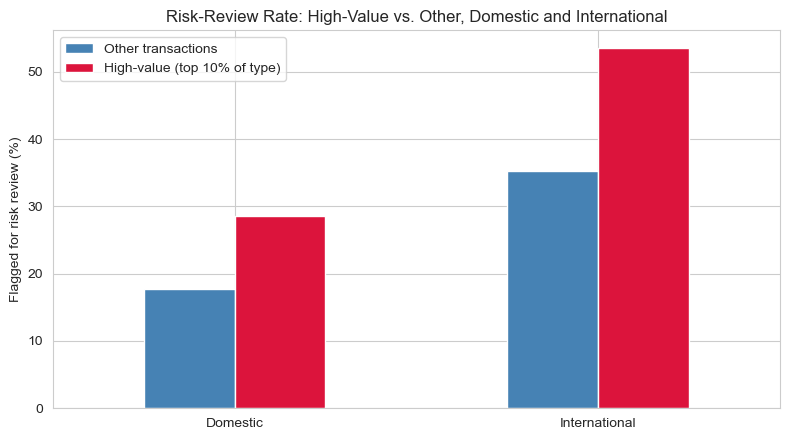

In [14]:
# 90th percentile of Amount_NGN within each transaction type
p90 = txn.groupby("Transaction_Type")["Amount_NGN"].transform(lambda s: s.quantile(0.9))
txn["High_Value"] = txn["Amount_NGN"] > p90

hv = txn[txn["High_Value"]]
normal = txn[~txn["High_Value"]]
p_hv = chi_square_p(hv["Flagged"].sum(), len(hv), normal["Flagged"].sum(), len(normal))
print(f"High-value: {hv['Flagged'].sum()} of {len(hv):,} flagged = {pct1(hv['Flagged'].mean())}")
print(f"Others:     {normal['Flagged'].sum():,} of {len(normal):,} flagged = {pct1(normal['Flagged'].mean())}")
print("Chi-square:", p3(p_hv))

# Is it just an international effect? Test inside each group separately.
print()
hv_split = {}
for label, flag in [("Domestic", "No"), ("International", "Yes")]:
    subset = txn[txn["International_Transaction"] == flag]
    a = subset[subset["High_Value"]]
    b = subset[~subset["High_Value"]]
    p = chi_square_p(a["Flagged"].sum(), len(a), b["Flagged"].sum(), len(b))
    hv_split[label] = p
    print(f"{label}: high-value {pct1(a['Flagged'].mean())} (n={len(a):,}) vs. other {pct1(b['Flagged'].mean())} (n={len(b):,}), {p3(p)}")

median_by_type = txn.groupby("Transaction_Type")["Amount_NGN"].median()
print(f"\nMedian amount: {median_by_type.idxmax()} ₦{median_by_type.max():,.0f} vs. {median_by_type.idxmin()} ₦{median_by_type.min():,.0f}")

rates = txn.groupby(["International_Transaction", "High_Value"])["Flagged"].mean().unstack() * 100
rates.index = ["Domestic", "International"]
rates.columns = ["Other transactions", "High-value (top 10% of type)"]
rates.plot(kind="bar", color=["steelblue", "crimson"], rot=0)
plt.ylabel("Flagged for risk review (%)")
plt.title("Risk-Review Rate: High-Value vs. Other, Domestic and International")
plt.tight_layout()
plt.show()

### What explains how often a customer transacts?
Claim: nothing in the customer profile I tested predicts transaction frequency.

In [15]:
txn_count = transactions.groupby("Customer_ID").size().rename("Txn_Count")
cust = customers.merge(txn_count, on="Customer_ID", how="left").fillna({"Txn_Count": 0})
cust["Engagement_Quartile"] = pd.qcut(cust["Digital_Engagement_Score"], 4, labels=False)

print(f"Average transactions per customer: {cust['Txn_Count'].mean():.1f}\n")

# Numeric attributes: correlation with transaction count
r_eng, p_eng_corr = stats.pearsonr(cust["Digital_Engagement_Score"], cust["Txn_Count"])
r_ten, p_ten = stats.pearsonr(cust["Tenure_Months"], cust["Txn_Count"])
r_age, p_age = stats.pearsonr(cust["Age"], cust["Txn_Count"])

# Grouped attributes: ANOVA across groups
def anova_p(column):
    groups = [g["Txn_Count"].values for _, g in cust.groupby(column)]
    return stats.f_oneway(*groups)[1]

p_eng_anova = anova_p("Engagement_Quartile")
p_income = anova_p("Monthly_Income_Band")
p_account = anova_p("Account_Type")
p_segment = anova_p("Customer_Segment")

print("Engagement quartile means:", ", ".join(f"{v:.2f}" for v in cust.groupby("Engagement_Quartile")["Txn_Count"].mean()))
activity = pd.DataFrame({
    "Attribute": ["Digital engagement score", "Tenure (months)", "Age", "Monthly income band", "Account type", "Customer segment"],
    "Test": ["Correlation", "Correlation", "Correlation", "ANOVA", "ANOVA", "ANOVA"],
    "Result": [f"r = {r_eng:.3f}", f"r = {r_ten:.3f}", f"r = {r_age:.3f}", "", "", ""],
    "Significance": [p3(p_eng_anova) + " (ANOVA across quartiles)", p3(p_ten), p3(p_age), p3(p_income), p3(p_account), p3(p_segment)],
})
activity

Average transactions per customer: 8.0

Engagement quartile means: 7.94, 7.90, 7.90, 8.26


,Attribute,Test,Result,Significance
0,Digital engagement score,Correlation,r = 0.038,p = 0.238 (ANOVA across quartiles)
1,Tenure (months),Correlation,r = -0.005,p = 0.839
2,Age,Correlation,r = -0.002,p = 0.936
3,Monthly income band,ANOVA,,p = 0.262
4,Account type,ANOVA,,p = 0.994
5,Customer segment,ANOVA,,p = 0.483


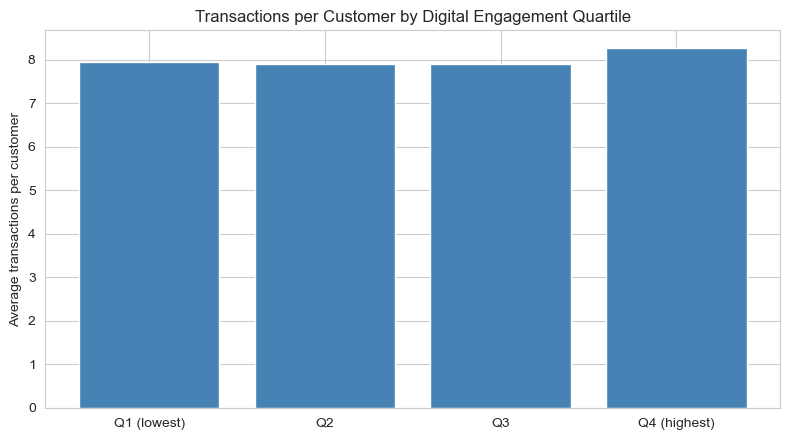

In [16]:
quartile_means = cust.groupby("Engagement_Quartile")["Txn_Count"].mean()
plt.figure()
plt.bar(["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"], quartile_means.values, color="steelblue")
plt.ylabel("Average transactions per customer")
plt.title("Transactions per Customer by Digital Engagement Quartile")
plt.tight_layout()
plt.show()

### The February "dip"
Claim: the apparent drop in February is just February having fewer days.

Monthly counts: 4,133 / 3,734 / 4,133
Per-day rate:   133.3 / 133.4 / 133.3
Apparent February drop vs. January: 9.7%


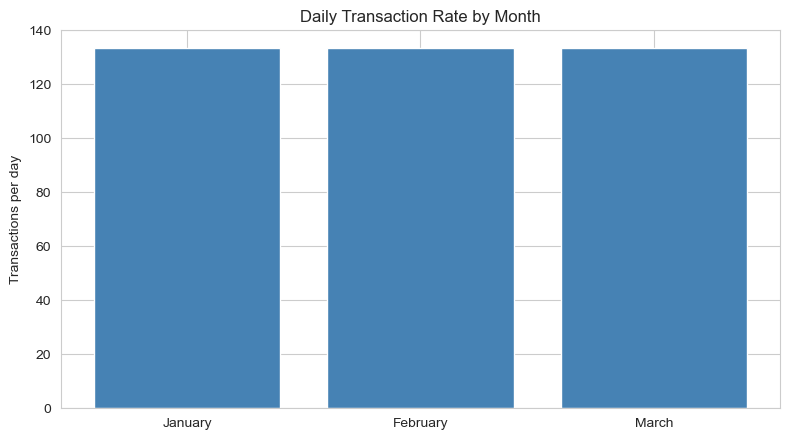

In [17]:
monthly_counts = transactions.groupby(transactions["Transaction_DateTime"].dt.month).size()
days_in_month = pd.Series({1: 31, 2: 28, 3: 31})   # January, February, March 2026
daily_rate = monthly_counts / days_in_month

print("Monthly counts:", " / ".join(f"{v:,}" for v in monthly_counts))
print("Per-day rate:  ", " / ".join(f"{v:.1f}" for v in daily_rate))
print(f"Apparent February drop vs. January: {(1 - monthly_counts[2] / monthly_counts[1]) * 100:.1f}%")

plt.figure()
plt.bar(["January", "February", "March"], daily_rate.values, color="steelblue")
plt.ylabel("Transactions per day")
plt.title("Daily Transaction Rate by Month")
plt.tight_layout()
plt.show()

### Channel reliability
Claim (weakened after testing): Mobile App has the lowest success rate, but the gap is small and the channels as a group are not significantly different.

Mobile App: 89.75% (n=5,102) vs. other channels 91.00%, p = 0.021
Mobile App vs. ATM (91.70%, n=1,747): p = 0.018
Across all five channels: p = 0.143
Gap: 1.25 percentage points, about 64 more successful transactions if Mobile App matched the others


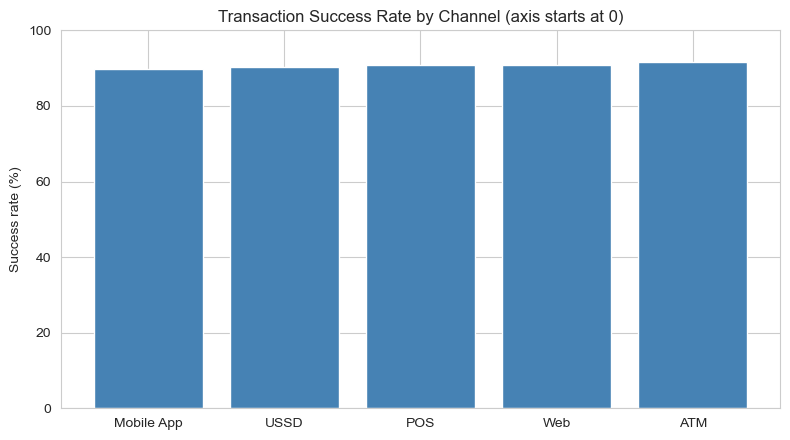

In [18]:
mobile = txn[txn["Channel"] == "Mobile App"]
other_channels = txn[txn["Channel"] != "Mobile App"]
atm = txn[txn["Channel"] == "ATM"]

p_mobile_rest = chi_square_p(mobile["Successful"].sum(), len(mobile), other_channels["Successful"].sum(), len(other_channels))
p_mobile_atm = chi_square_p(mobile["Successful"].sum(), len(mobile), atm["Successful"].sum(), len(atm))
p_all_channels = stats.chi2_contingency(pd.crosstab(txn["Channel"], txn["Successful"]))[1]

print(f"Mobile App: {pct2(mobile['Successful'].mean())} (n={len(mobile):,}) vs. other channels {pct2(other_channels['Successful'].mean())}, {p3(p_mobile_rest)}")
print(f"Mobile App vs. ATM ({pct2(atm['Successful'].mean())}, n={len(atm):,}): {p3(p_mobile_atm)}")
print(f"Across all five channels: {p3(p_all_channels)}")

expected_successes = len(mobile) * other_channels["Successful"].mean()
extra_successes = expected_successes - mobile["Successful"].sum()
gap_points = (other_channels["Successful"].mean() - mobile["Successful"].mean()) * 100
print(f"Gap: {gap_points:.2f} percentage points, about {extra_successes:.0f} more successful transactions if Mobile App matched the others")

success_by_channel = txn.groupby("Channel")["Successful"].mean().sort_values() * 100
plt.figure()
plt.bar(success_by_channel.index, success_by_channel.values, color="steelblue")
plt.ylim(0, 100)
plt.ylabel("Success rate (%)")
plt.title("Transaction Success Rate by Channel (axis starts at 0)")
plt.tight_layout()
plt.show()

### Risk-review rate by customer segment
Claim (not supported after testing): Premium customers carry the highest risk-review exposure.

In [19]:
segment_rates = txn.groupby("Customer_Segment")["Flagged"].mean().sort_values()
for segment, rate in segment_rates.items():
    print(f"{segment:<9} {pct2(rate)}")

p_segment_risk = stats.chi2_contingency(pd.crosstab(txn["Customer_Segment"], txn["Flagged"]))[1]
premium = txn[txn["Customer_Segment"] == "Premium"]
not_premium = txn[txn["Customer_Segment"] != "Premium"]
p_premium = chi_square_p(premium["Flagged"].sum(), len(premium), not_premium["Flagged"].sum(), len(not_premium))

print("\nChi-square across the four segments:", p3(p_segment_risk))
print(f"Premium {pct2(premium['Flagged'].mean())} vs. everyone else {pct2(not_premium['Flagged'].mean())}: {p3(p_premium)}")

Everyday  19.29%
SME       19.40%
Student   19.75%
Premium   20.33%

Chi-square across the four segments: p = 0.751
Premium 20.33% vs. everyone else 19.42%: p = 0.319


### The segment-by-channel grid
Claims: Student customers on Web have the weakest success rate; Premium customers on Web have the highest risk-review rate.

Both were found by picking the most extreme of 20 cells, which is exactly the situation where a result can look striking by chance. So each is tested three ways: against all other transactions, with a test across all 20 cells, and with a simulation.

In [20]:
txn["Cell"] = txn["Customer_Segment"] + " | " + txn["Channel"]
cells = txn.groupby("Cell").agg(n=("Successful", "size"),
                                success_rate=("Successful", "mean"),
                                flag_rate=("Flagged", "mean"))
print(f"Cell sizes range from {cells['n'].min()} to {cells['n'].max():,} transactions\n")

# Student on Web: success rate
is_sw = (txn["Customer_Segment"] == "Student") & (txn["Channel"] == "Web")
sw, not_sw = txn[is_sw], txn[~is_sw]
p_sw = chi_square_p(sw["Successful"].sum(), len(sw), not_sw["Successful"].sum(), len(not_sw))
print(f"Student on Web: {pct2(sw['Successful'].mean())} ({sw['Successful'].sum()} of {len(sw)}) vs. rest {pct2(not_sw['Successful'].mean())}, {p3(p_sw)}")

# Premium on Web: risk-review rate
is_pw = (txn["Customer_Segment"] == "Premium") & (txn["Channel"] == "Web")
pw, not_pw = txn[is_pw], txn[~is_pw]
p_pw = chi_square_p(pw["Flagged"].sum(), len(pw), not_pw["Flagged"].sum(), len(not_pw))
print(f"Premium on Web: {pct2(pw['Flagged'].mean())} ({pw['Flagged'].sum()} of {len(pw)}) vs. rest {pct2(not_pw['Flagged'].mean())}, {p3(p_pw)}")

# Do the 20 cells differ from each other more than chance would expect?
p_cells_success = stats.chi2_contingency(pd.crosstab(txn["Cell"], txn["Successful"]))[1]
p_cells_flag = stats.chi2_contingency(pd.crosstab(txn["Cell"], txn["Flagged"]))[1]
print(f"\nAcross all 20 cells: success rate {p3(p_cells_success)}, flag rate {p3(p_cells_flag)}")

Cell sizes range from 140 to 2,368 transactions

Student on Web: 88.07% (310 of 352) vs. rest 90.54%, p = 0.120
Premium on Web: 25.48% (92 of 361) vs. rest 19.42%, p = 0.004

Across all 20 cells: success rate p = 0.192, flag rate p = 0.274


### Simulation: how extreme is the best/worst of 20 cells by chance alone?
Generate 20,000 random datasets with the same 20 cell sizes and the same overall rates, but no real differences between cells. Each time, record the lowest success rate and the highest flag rate. Then count how often chance alone matches what the real data shows. The random seed is fixed, so the result is reproducible.

In [21]:
rng = np.random.default_rng(42)
n_runs = 20000
sizes = cells["n"].values
overall_success = txn["Successful"].mean()
overall_flag = txn["Flagged"].mean()

lowest_success_by_chance = np.array([(rng.binomial(sizes, overall_success) / sizes).min() for _ in range(n_runs)])
highest_flag_by_chance = np.array([(rng.binomial(sizes, overall_flag) / sizes).max() for _ in range(n_runs)])

share_low = (lowest_success_by_chance <= cells["success_rate"].min()).mean()
share_high = (highest_flag_by_chance >= cells["flag_rate"].max()).mean()

print(f"Lowest success cell in the real data: {pct2(cells['success_rate'].min())} ({cells['success_rate'].idxmin()})")
print(f"  Chance alone produced a lowest cell at least that low in {share_low*100:.0f}% of simulations")
print(f"Highest flag cell in the real data:   {pct2(cells['flag_rate'].max())} ({cells['flag_rate'].idxmax()})")
print(f"  Chance alone produced a highest cell at least that high in {share_high*100:.0f}% of simulations")

Lowest success cell in the real data: 88.07% (Student | Web)
  Chance alone produced a lowest cell at least that low in 73% of simulations
Highest flag cell in the real data:   25.48% (Premium | Web)
  Chance alone produced a highest cell at least that high in 14% of simulations


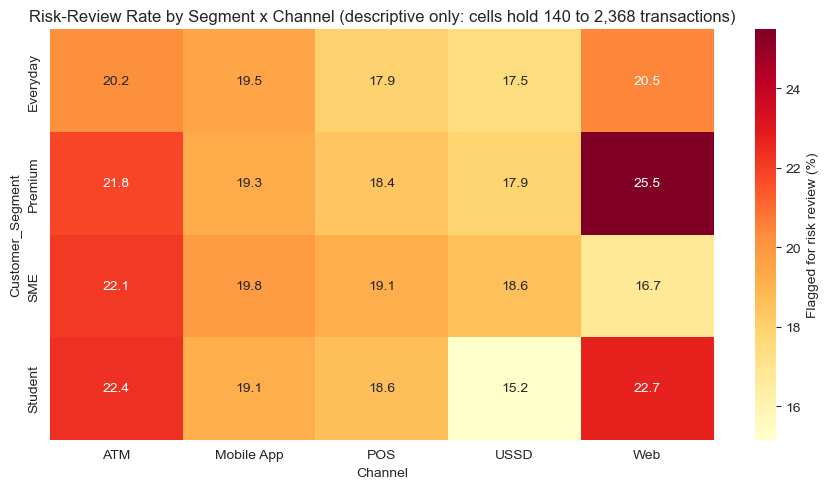

In [22]:
flag_grid = txn.pivot_table(index="Customer_Segment", columns="Channel", values="Flagged", aggfunc="mean") * 100

plt.figure(figsize=(9, 5))
sns.heatmap(flag_grid, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Flagged for risk review (%)"})
plt.title("Risk-Review Rate by Segment x Channel (descriptive only: cells hold 140 to 2,368 transactions)")
plt.tight_layout()
plt.show()

### Summary of results
This table matches the findings in the Week 4 document, so the numbers can be checked side by side.

In [23]:
summary = pd.DataFrame([
    ["International transactions flagged more", f"{pct1(intl['Flagged'].mean())} vs. {pct1(dom['Flagged'].mean())}", p3(p_intl), "Validated"],
    ["High-value transactions flagged more", f"{pct1(hv['Flagged'].mean())} vs. {pct1(normal['Flagged'].mean())}", p3(p_hv), "Validated (holds in domestic and international)"],
    ["Engagement predicts activity", f"r = {r_eng:.3f}", p3(p_eng_anova), "Validated: no relationship (nor do the other five attributes)"],
    ["February dip is real", f"{daily_rate[1]:.1f} / {daily_rate[2]:.1f} / {daily_rate[3]:.1f} per day", "n/a", "Withdrawn: calendar artifact"],
    ["Mobile App least reliable", f"{pct2(mobile['Successful'].mean())} vs. {pct2(other_channels['Successful'].mean())}", p3(p_all_channels) + " across channels", "Weakened: small gap"],
    ["Premium highest-risk segment", f"{pct2(premium['Flagged'].mean())} vs. {pct2(not_premium['Flagged'].mean())}", p3(p_segment_risk) + " across segments", "Not supported"],
    ["Student on Web weakest pairing", f"{pct2(sw['Successful'].mean())} vs. {pct2(not_sw['Successful'].mean())}", p3(p_sw), f"Not supported (chance gives this {share_low*100:.0f}% of the time)"],
    ["Premium on Web risk hotspot", f"{pct2(pw['Flagged'].mean())} vs. {pct2(not_pw['Flagged'].mean())}", p3(p_pw) + " alone", f"Suggestive only (chance gives this {share_high*100:.0f}% of the time)"],
], columns=["Finding", "Key result", "Significance", "Conclusion"])
summary

,Finding,Key result,Significance,Conclusion
0,International transactions flagged more,36.9% vs. 18.9%,p < 0.001,Validated
1,High-value transactions flagged more,29.5% vs. 18.5%,p < 0.001,Validated (holds in domestic and international)
2,Engagement predicts activity,r = 0.038,p = 0.238,Validated: no relationship (nor do the other f...
3,February dip is real,133.3 / 133.4 / 133.3 per day,n/a,Withdrawn: calendar artifact
4,Mobile App least reliable,89.75% vs. 91.00%,p = 0.143 across channels,Weakened: small gap
5,Premium highest-risk segment,20.33% vs. 19.42%,p = 0.751 across segments,Not supported
6,Student on Web weakest pairing,88.07% vs. 90.54%,p = 0.120,Not supported (chance gives this 73% of the time)
7,Premium on Web risk hotspot,25.48% vs. 19.42%,p = 0.004 alone,Suggestive only (chance gives this 14% of the ...


### Limitations
The data is synthetic and covers three months (January to March 2026).
Risk_Review_Flag is an educational label, not a fraud determination, so nothing here says anything about real fraud.
The p-values assume transactions are independent of each other.
Many tests were run, so a few weak results could look significant by accident. The simulation guards against this for the grid findings; the international and high-value results are far below any plausible threshold.
